# HydroSense-Kenya: Scientific Computing for Smart Irrigation 
## Milestone 1: Problem Framing and Python Foundation
---
1. Scientific Problem Statement

Agriculture remains the backbone of Kenya's economy, yet it faces significant challenges due to climate variability and water scarcity, particularly in semi-arid regions and high-production zones like Kiambu County. Traditional irrigation often relies on fixed schedules or manual observation, leading to either water wastage or crop stress from under-irrigation.

HydroSense-Kenya is designed to address these inefficiencies through a scientific computing approach. By modeling the daily water balance—accounting for rainfall, solar intensity, wind speed, and soil characteristics—the system aims to provide a data-driven decision-making framework. This project implements a discrete water balance model to simulate soil moisture dynamics and optimize irrigation schedules, ensuring maximum crop yield with minimal water expenditure.

## Mathematical Foundation
---
### 2. Core Mathematical models to simulate the agricultural environment
We implement two primary scientific models:

**[A]**. The Discrete Water Balance Model: The soil moisture at the next time step ($S_{t+1}$) is calculated using the current moisture and the flux of water entering and leaving the system:$$S_{t+1} = S_t + R_t + I_t - ET_t - D_t$$
Where:

$S$: Soil Moisture

$R$: Rainfall

$I$: Irrigation

$ET$: Evapotranspiration

$D$: Drainage/Runoff

---

**[B]**. Evapotranspiration (ET) Model: We use a simplified empirical model to estimate water loss to the atmosphere:$$ET = \max(0, 0.12T + 0.35W + 2.4Solar - 0.025H)$$
Where:

$T$: temperature 

$W$: wind speed

$Solar$: solar index

$H$: humidity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os,sys

# Loading the datasets using the structure defined in the project brief
def load_datasets():
    base_path = "../data/raw"
    weather = pd.read_csv(os.path.join(base_path, "weather_daily.csv"), na_values=['NA', ''])
    soil = pd.read_csv(os.path.join(base_path, "soil_sensor_data.csv"), na_values=['NA', ''])
    params = pd.read_csv(os.path.join(base_path, "crop_zone_parameters.csv"), na_values=['NA', ''])
    return weather, soil, params

weather_df, soil_df, params_df = load_datasets()

In [ ]:
def calculate_evapotranspiration(temp, wind, solar, humidity):
    """
    Calculates the daily evapotranspiration rate based on atmospheric conditions.
    """
    et = (0.12 * temp) + (0.35 * wind) + (2.4 * solar) - (0.025 * humidity)
    return max(0, et)

def calculate_water_balance(s_curr, rain, irrigation, et, drainage):
    """
    Computes the soil moisture for the next time step.
    """
    s_next = s_curr + rain + irrigation - et - drainage
    return s_next

### 3. Data Dictionary



In [ ]:
sys.path.append(os.path.abspath("../src"))
from data_cleaning import load_raw_datasets, generate_structural_dictionary

# Ingest raw data using Level 1 parsing rules
weather_raw, soil_raw = load_raw_datasets()

# Generate the structural data dictionaries automatically
weather_structure = generate_structural_dictionary(weather_raw, "Raw Weather Data")
display(weather_structure)


===Structural Dictionary: Raw Weather Data ===
Total Rows: 30 | Total Features: 6



,Data Type,Non-Null Count,Null Count,Null Percentage (%),Unique Values
date,datetime64[us],30,0,0.00,30
rainfall_mm,float64,29,1,3.33,22
temperature_c,float64,30,0,0.00,24
humidity_pct,float64,29,1,3.33,29
wind_speed_mps,float64,30,0,0.00,28
solar_index,float64,30,0,0.00,19


## 4. Assumptions and Initial Limitations

For the Level 1 implementation, the following assumptions are made:

    1.Uniform Soil Distribution: Soil moisture is assumed to be uniform across a single zone.

    2.Instantaneous Drainage: Water exceeding the field capacity is assumed to drain instantly within the 24-hour cycle.

    3.Sensor Accuracy: Initial readings are taken at face value before the cleaning pipeline is implemented in Level 4.

# Initial Visualization Implementation
---
## 5. Initial Data Exploration: Soil Moisture Trends

To understand the baseline dynamics of our farm zones, we plot the soil moisture percentage over the 30-day period. This helps us visualize the rate of depletion and identify potential sensor failures.

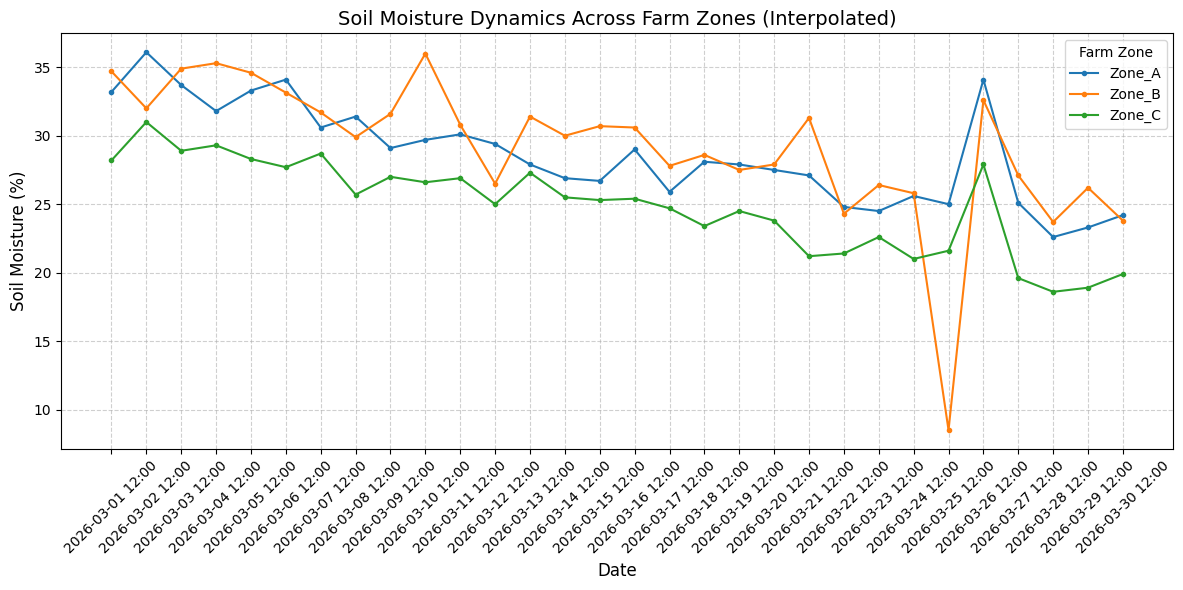

In [ ]:
import matplotlib.pyplot as plt

# Group by zone and apply linear interpolation to fill NaN values
soil_df['soil_moisture_pct_fixed'] = soil_df.groupby('zone_id')['soil_moisture_pct'].transform(
    lambda group: group.interpolate(method='linear')
)

#plot the data
plt.figure(figsize=(12, 6))
for zone in soil_df['zone_id'].unique():
    zone_data = soil_df[soil_df['zone_id'] == zone]
    plt.plot(zone_data['timestamp'], zone_data['soil_moisture_pct_fixed'], marker='.', label=f'{zone}')

plt.title('Soil Moisture Dynamics Across Farm Zones (Interpolated)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Soil Moisture (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Farm Zone")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Interpretation of Initial Results

The plot above reveals several key insights regarding the raw dataset:

    1. General Trend: Most zones show a gradual decline in soil moisture, which matches the expected behavior of evapotranspiration and drainage in the absence of heavy irrigation.

    2. Zone-Specific Variations: Each zone starts at a different moisture level and depletes at a different rate, likely due to the specific crop parameters (maize vs. tomato) defined in our parameters file.

    3. Data Anomalies Detected: * Zone B Anomaly: Around March 25th, there is a precipitous drop in Zone B's moisture reading to nearly 8%. This is likely one of the intentional sensor faults or "NA" values that we must address in Level 4.

    4. Stability: Outside of the anomalies, the sensor data appears relatively consistent, confirming that our load_datasets function correctly handled the basic CSV ingestion.

## 7. Exploratory Data Analysis: Weather Drivers

To understand the environmental factors affecting crop water requirements, we plot Rainfall against Temperature. These two variables heavily influence the Evapotranspiration (ET) rate and the natural replenishment of soil moisture.

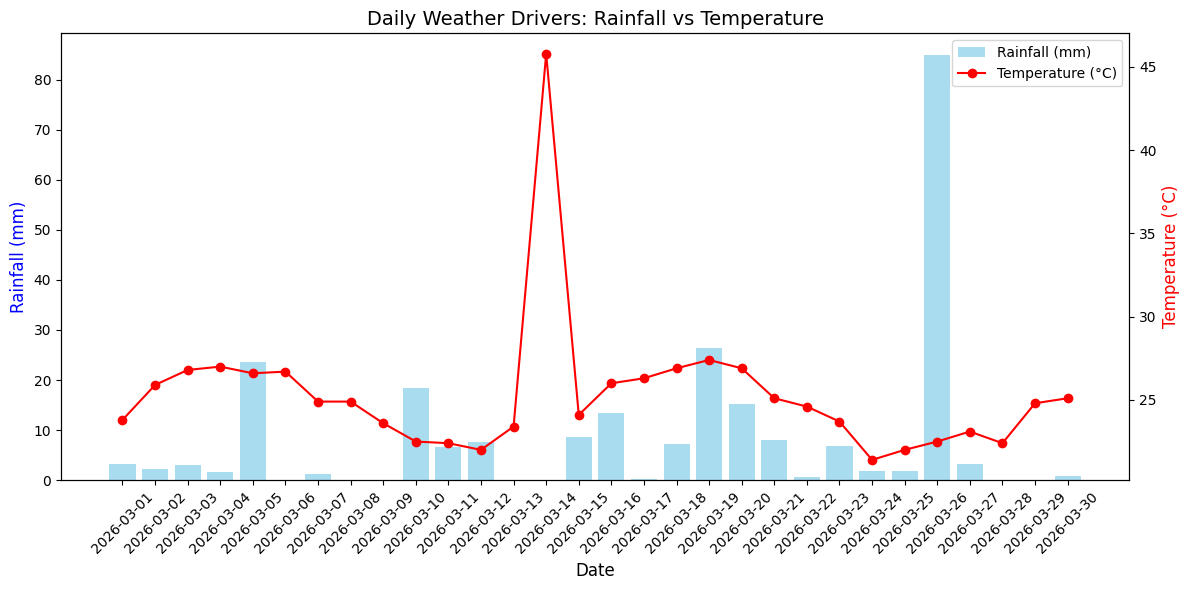

In [ ]:
# Plotting Rainfall and Temperature on dual axes
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Bar chart for rainfall (Left y-axis)
ax1.bar(weather_df['date'], weather_df['rainfall_mm'], color='skyblue', alpha=0.7, label='Rainfall (mm)')
# Line chart for temperature (Right y-axis)
ax2.plot(weather_df['date'], weather_df['temperature_c'], color='red', marker='o', label='Temperature (°C)')

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Rainfall (mm)', color='blue', fontsize=12)
ax2.set_ylabel('Temperature (°C)', color='red', fontsize=12)
plt.title('Daily Weather Drivers: Rainfall vs Temperature', fontsize=14)
ax1.tick_params(axis='x', rotation=45)

# Combining legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.show()

## Interpretation of Weather Trends
---
Scientific Interpretation: The dual-axis plot illustrates the inverse relationship commonly found in microclimates: days with significant rainfall (e.g., the massive spike on March 25th of 85mm) correspond to lower daily temperatures. Conversely, dry spells (e.g., mid-March) correspond to temperature spikes, which will exponentially increase our simulated Evapotranspiration (ET) and rapidly deplete soil moisture.